# สมุดโน้ตทำความสะอาดข้อมูลคู่แข่งทางธุรกิจ (Competitors Cleaning)
จัดการเรื่องจุดซ้ำซ้อน (Deduplication) อุดรอยรั่วค่าว่าง และบันทึกรูปภาพประเมินความสมบูรณ์ของข้อมูล

---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_json("../../data/interim/bangkok_competitors.json")
df

,name,amenity_type,cuisine,opening_hours,street,postcode,latitude,longitude
0,Manna,restaurant,general,NaN,NaN,NaN,13.747702,100.534554
1,Zen,restaurant,general,NaN,NaN,NaN,13.728106,100.533141
2,Molly Malone's,bar,general,NaN,NaN,NaN,13.727445,100.533499
3,Pola Pola,cafe,general,NaN,NaN,NaN,13.727240,100.533542
4,Cafe Bangrak,cafe,general,NaN,NaN,NaN,13.728916,100.535583
...,...,...,...,...,...,...,...,...
9141,ครัวกลางน้ำ,restaurant,general,NaN,NaN,10150,13.560881,100.420075
9142,ครัวคุณอรซีฟู้ด,restaurant,general,NaN,ถนนบางขุนเทียนชายทะเล,10150,13.569601,100.420620
9143,ปลาอยู่เย็น,restaurant,general,NaN,NaN,10170,13.768306,100.445662
9144,แจว,restaurant,general,NaN,ซอยประดิพัทธ์ 4,10400,13.784603,100.535650


### 🔍 ตรวจสอบและรายงานค่าว่างในชุดข้อมูล (Data Observability)
สร้าง Heatmap เพื่อแสดงช่องว่างของข้อมูลที่ไม่มีชื่อหรือข้อมูลพิกัดสูญหาย


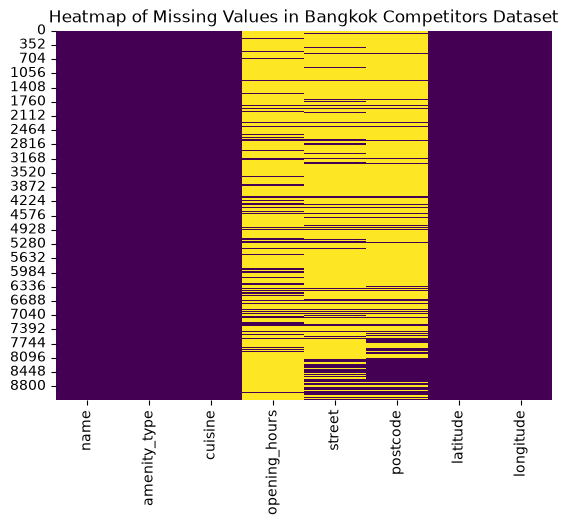

In [5]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Heatmap of Missing Values in Bangkok Competitors Dataset")
plt.show()

In [7]:
df_competitors = df[['name', 'amenity_type', 'cuisine', 'latitude', 'longitude']]
df_competitors

,name,amenity_type,cuisine,latitude,longitude
0,Manna,restaurant,general,13.747702,100.534554
1,Zen,restaurant,general,13.728106,100.533141
2,Molly Malone's,bar,general,13.727445,100.533499
3,Pola Pola,cafe,general,13.727240,100.533542
4,Cafe Bangrak,cafe,general,13.728916,100.535583
...,...,...,...,...,...
9141,ครัวกลางน้ำ,restaurant,general,13.560881,100.420075
9142,ครัวคุณอรซีฟู้ด,restaurant,general,13.569601,100.420620
9143,ปลาอยู่เย็น,restaurant,general,13.768306,100.445662
9144,แจว,restaurant,general,13.784603,100.535650


### 🔍 ตรวจสอบและรายงานค่าว่างในชุดข้อมูล (Data Observability)
สร้าง Heatmap เพื่อแสดงช่องว่างของข้อมูลที่ไม่มีชื่อหรือข้อมูลพิกัดสูญหาย


In [8]:
df_competitors.isnull().sum()

name            0
amenity_type    0
cuisine         0
latitude        0
longitude       0
dtype: int64

### 💾 บันทึกผลลัพธ์ข้อมูลคลีนระดับ Processed
ส่งออกข้อมูลที่ทำความสะอาดเรียบร้อยเป็นไฟล์ CSV พร้อมป้อนเข้าแบบจำลอง


In [ ]:
df_competitors.to_csv("../../data/processed/bangkok_competitors_clean.csv", index=False)